# Synthetic-mode recovery with spectral-infill background

Background-signal counterpart of `result_initial_tests.ipynb`. Synthetic modes are recovered from the resolved-plus-background record, and spatial quality is measured relative to the background-derived similarity threshold produced by `result_background.ipynb`.

## Preamble

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application


## Construct the synthetic suite and background-signal record

In [16]:
# Defining test parameters

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# Construct the common synthetic suite and retain only the
# resolved-plus-background record used throughout this notebook.
record_dict_global, syn_suite_info_global = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=15)
background_record_dict = {
    "background": record_dict_global["background"]
}


# defining notebook global colours for each mode in plotting
for i, mode_key in enumerate(syn_suite_info_global):
    syn_suite_info_global[mode_key]["colour"] = tol_muted[i % len(tol_muted)]
    

# Background-signal exact-DMD results

## Rank vs degree effects

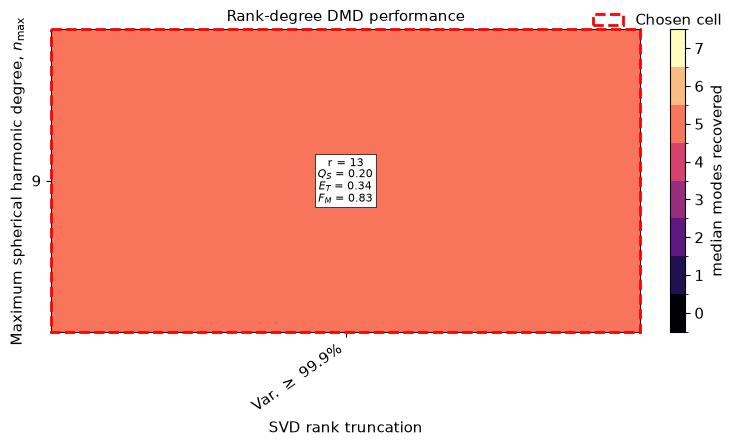

(<Figure size 725x435 with 2 Axes>,
 <Axes: title={'center': 'Rank-degree DMD performance'}, xlabel='SVD rank truncation', ylabel='Maximum spherical harmonic degree, $n_{\\max}$'>,
 <matplotlib.colorbar.Colorbar at 0x77a4494f4c90>)

In [17]:

# nmax values to test
nmax_list = [9]

# svd rank values to test
svd_rank_list = [0.999]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)


dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":6,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

Rank_Degree_Heatmap(background_record_dict, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings,
                    chosen_rank_degree=(0.999, 9),
                    similarity_threshold_key="background",
                    )

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.0499485682542344e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.285413747382563e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.5652622541424284e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.0806607564411384e+16. Consider preprocessing data, passing in augmente

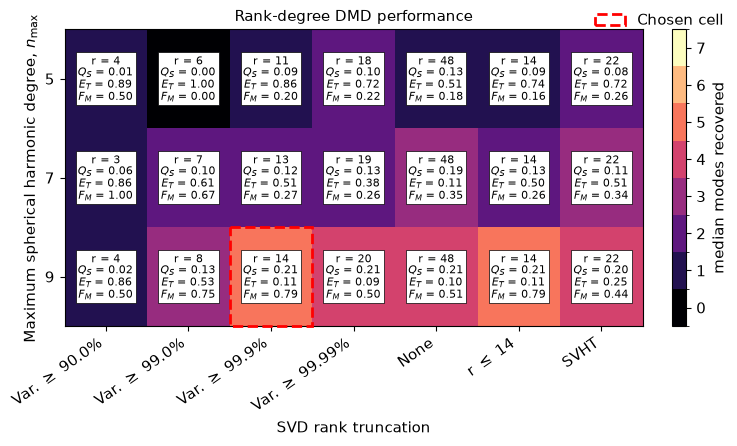

(<Figure size 725x435 with 2 Axes>,
 <Axes: title={'center': 'Rank-degree DMD performance'}, xlabel='SVD rank truncation', ylabel='Maximum spherical harmonic degree, $n_{\\max}$'>,
 <matplotlib.colorbar.Colorbar at 0x77a44886afd0>)

In [18]:

# nmax values to test
nmax_list = [5, 7, 9]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)


dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

Rank_Degree_Heatmap(background_record_dict, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings,
                    chosen_rank_degree=(0.999, 9),
                    similarity_threshold_key="background",
                    )

## Uncertainty effects on optimal rank vs degree

/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


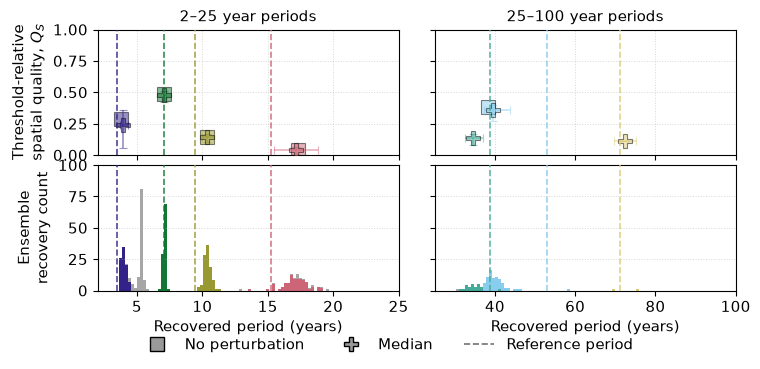

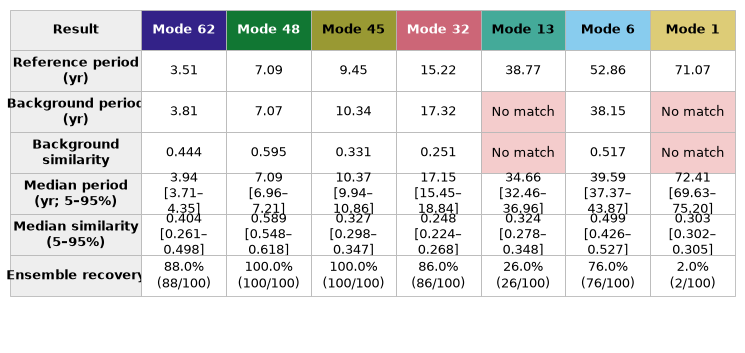

In [19]:


# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":1,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

nmax_choice = 9
svd_rank_choice = 0.999
# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run(background_record_dict, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

similarity_threshold = similarity_thresholds["background"][str(nmax_choice)]

non_perturbed_record = "background"

similarity_figure, similarity_axes = Plot_Single_Run_Ensemble_Results(
    results_dict, syn_suite_info_global, total_unmatched_periods,
    similarity_threshold, record_markers, record_plotting_params,
    figure_width=text_width, non_perturbed_record=non_perturbed_record,
)

plt.savefig(f"{RESULT_DIR}/waves_in_background_no_hankel.png", dpi=300, bbox_inches="tight")


summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    results_dict, syn_suite_info_global,
    non_perturbed_record=non_perturbed_record,
    ensemble_percentage_basis="attempted",
)
plt.show()

# Background-signal Hankel-DMD results

## Hankel embedding depth parameter test

In [20]:

nmax_choice = 9
svd_rank_choice = 0.999

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

hankel_d_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]#, 9, 10, 11, 12, 13, 14]
#hankel_d_list = [0, 4, 8, 12, 16, 20]
#hankel_d_list = [0, 8, 9, 10, 11, 12]
num_d = len(hankel_d_list)
similarity_threshold = similarity_thresholds["background"][str(nmax_choice)]


# code to make heatmap - add into heatmap plotter at some point
d_match_results = {
    "median": np.zeros(num_d),
    "p95": np.zeros(num_d),
    "p05": np.zeros(num_d),
} 
# initialising mode performance outcomes
mode_recovery_performance = {}

for mode_num in syn_suite_info_global:
    mode_recovery_performance[mode_num] = {
        "spatial_quality": {
            "median": np.zeros(num_d),
            "p05": np.zeros(num_d),
            "p95": np.zeros(num_d),
        },
        "match_period_errors": {
            "median": np.ones(num_d),
            "p05": np.ones(num_d),
            "p95": np.ones(num_d),
        },
        "runs_with_mode_match":np.zeros(num_d)
    }


# for each embedding d to be tested
for d_idx, embedding_d in enumerate(hankel_d_list):

    if embedding_d > 0:
        dmd_settings["hankel_flag"] = True
        dmd_settings["embedding_d"] = embedding_d


    # getting output of dmd for a run with a specific nmax, svd rank
    results_dict = Pipeline_Run(background_record_dict, syn_suite_info_global, 
            dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
            ensemble_settings=ensemble_settings)

    results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

    d_match_results["median"][d_idx] = results_dict["median"]["match_count"]["value"]
    d_match_results["p95"][d_idx] = results_dict["median"]["match_count"]["p95"]
    d_match_results["p05"][d_idx] = results_dict["median"]["match_count"]["p05"]

    # for each d - want the performance of each mode
    for mode_num in syn_suite_info_global:
        
        mode_results = results_dict["median"][mode_num]

        runs_with_match = mode_results["runs_with_mode_match"]
        mode_recovery_performance[mode_num]["runs_with_mode_match"][d_idx] = runs_with_match

        if runs_with_match > 0:
            for percentile, result_key in (
                ("median", "value"),
                ("p05", "p05"),
                ("p95", "p95"),
            ):
                similarity = mode_results["match_similarities"][result_key]
                spatial_quality = (
                    (similarity - similarity_threshold)
                    / (1 - similarity_threshold)
                )
                if not -1e-12 <= spatial_quality <= 1 + 1e-12:
                    raise ValueError(
                        f"Invalid threshold-relative spatial quality "
                        f"{spatial_quality:.6f} for mode {mode_num}, "
                        f"embedding d={embedding_d}, {percentile}."
                    )
                mode_recovery_performance[mode_num]["spatial_quality"][percentile][d_idx] = (
                    np.clip(spatial_quality, 0.0, 1.0)
                )
                mode_recovery_performance[mode_num]["match_period_errors"][percentile][d_idx] = (
                    mode_results["match_period_errors"][result_key]
                )
        else:
            # Match the missing-mode convention used by Rank_Degree_Heatmap.
            for percentile in ("median", "p05", "p95"):
                mode_recovery_performance[mode_num]["spatial_quality"][percentile][d_idx] = 0.0
                mode_recovery_performance[mode_num]["match_period_errors"][percentile][d_idx] = 1.0

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1592: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


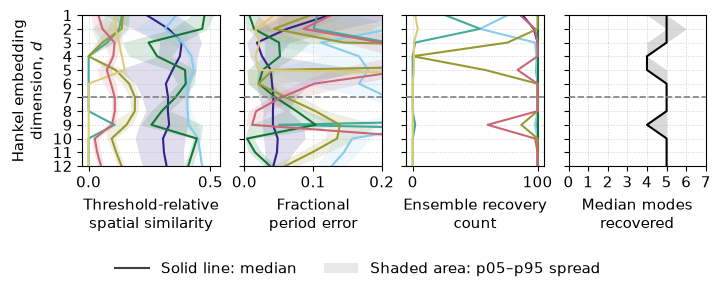

In [21]:
chosen_embedding_d = 7

embedding_figure, embedding_axes = Plot_Hankel_Embedding_Performance(
    hankel_d_list, mode_recovery_performance, syn_suite_info_global,
    ensemble_match_counts=d_match_results,
    figure_width=text_width, chosen_embedding_d=chosen_embedding_d,
)

plt.savefig(f"{RESULT_DIR}/waves_in_background_hankel_d_sweep.png", dpi=300, bbox_inches="tight")

plt.show()

## Uncertainty effects on optimal hankel choice

In [22]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":7,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":100,
    "record_for_ensemble":"background"
}

nmax_choice = 9
svd_rank_choice = 0.999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict, total_unmatched_periods, rec_modes = Pipeline_Run(background_record_dict, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings, total_unmatched_period_return=True)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

In [23]:
print(rec_modes["periods"])

[ 3.61775552  5.20033326         inf 41.59972567 16.060365    8.94400447
  6.79548359]


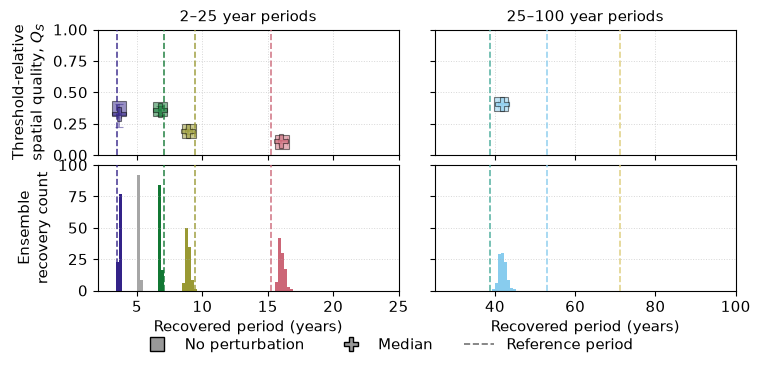

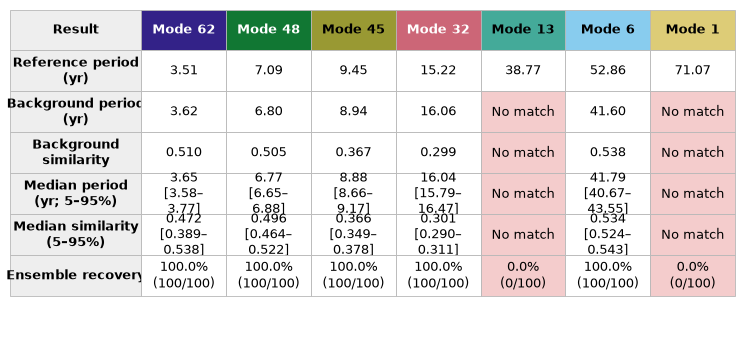

In [24]:
similarity_threshold = similarity_thresholds[
    "background"
][str(nmax_choice)]

non_perturbed_record = "background"

similarity_figure, similarity_axes = Plot_Single_Run_Ensemble_Results(
    results_dict, syn_suite_info_global, total_unmatched_periods,
    similarity_threshold, record_markers, record_plotting_params,
    figure_width=text_width, non_perturbed_record=non_perturbed_record,
)
plt.savefig(f"{RESULT_DIR}/waves_in_background_d7.png", dpi=300, bbox_inches="tight")

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    results_dict, syn_suite_info_global,
    non_perturbed_record=non_perturbed_record,
    ensemble_percentage_basis="attempted",
)

plt.savefig(f"{RESULT_DIR}/waves_in_background_d7_table.png", dpi=300, bbox_inches="tight")

plt.show()

## Effect of hankel on degree-rank choice

In [25]:

# nmax values to test
nmax_list = [5, 7, 9]

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":6,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":50,
    "record_for_ensemble":"background"
}

Rank_Degree_Heatmap(background_record_dict, syn_suite_info_global, 
                    nmax_list, svd_rank_list, 
                    dmd_settings, ensemble_settings,
                    chosen_rank_degree=(0.999, 9),
                    similarity_threshold_key="background",
                    )

KeyboardInterrupt: 

In [ ]:
chosen_nmax = 9
chosen_svd_rank = 15
chosen_embedding_d = 6
n_ensemble = 100
control_period_limits = (3, 100)
background_seed = 42

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}



gnm_background = record_dict_global["background"]
A_control_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_background_control = Truncate_Gauss_Coeffs(
    gnm_background,
    tmax=chosen_nmax,
)
background_record = A_control_r @ gnm_background_control.T

background_dmd_modes = Run_DMD(
    background_record,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)
background_periods = np.asarray(background_dmd_modes['periods'], dtype=float)
period_min, period_max = control_period_limits
feasible_control_mask = (
    np.isfinite(background_periods)
    & (background_periods > period_min)
    & (background_periods < period_max)
)
feasible_control_indices = np.flatnonzero(feasible_control_mask)
feasible_control_indices = feasible_control_indices[
    np.argsort(background_periods[feasible_control_indices])
]

control_cmap = plt.get_cmap('viridis')
control_colours = control_cmap(
    np.linspace(0.10, 0.90, len(feasible_control_indices))
)
control_modes = {}
for control_number, (mode_index, mode_colour) in enumerate(
    zip(feasible_control_indices, control_colours),
    start=1,
):
    control_period = float(background_periods[mode_index])
    control_modes[f'C{control_number}'] = {
        'phasor': np.asarray(
            background_dmd_modes['phasors'][mode_index],
            dtype=complex,
        ),
        'eigenvalue': complex(
            background_dmd_modes['continuous_eigenvalues'][mode_index]
        ),
        'period': control_period,
        'true_period': control_period,
        'colour': mode_colour,
    }

print(f'Feasible control modes: {len(control_modes)}')
for control_key, control_info in control_modes.items():
    print(f"  {control_key}: {control_info['period']:.2f} years")

Feasible control modes: 7
  C1: 3.58 years
  C2: 4.30 years
  C3: 5.34 years
  C4: 6.78 years
  C5: 9.07 years
  C6: 15.41 years
  C7: 40.22 years


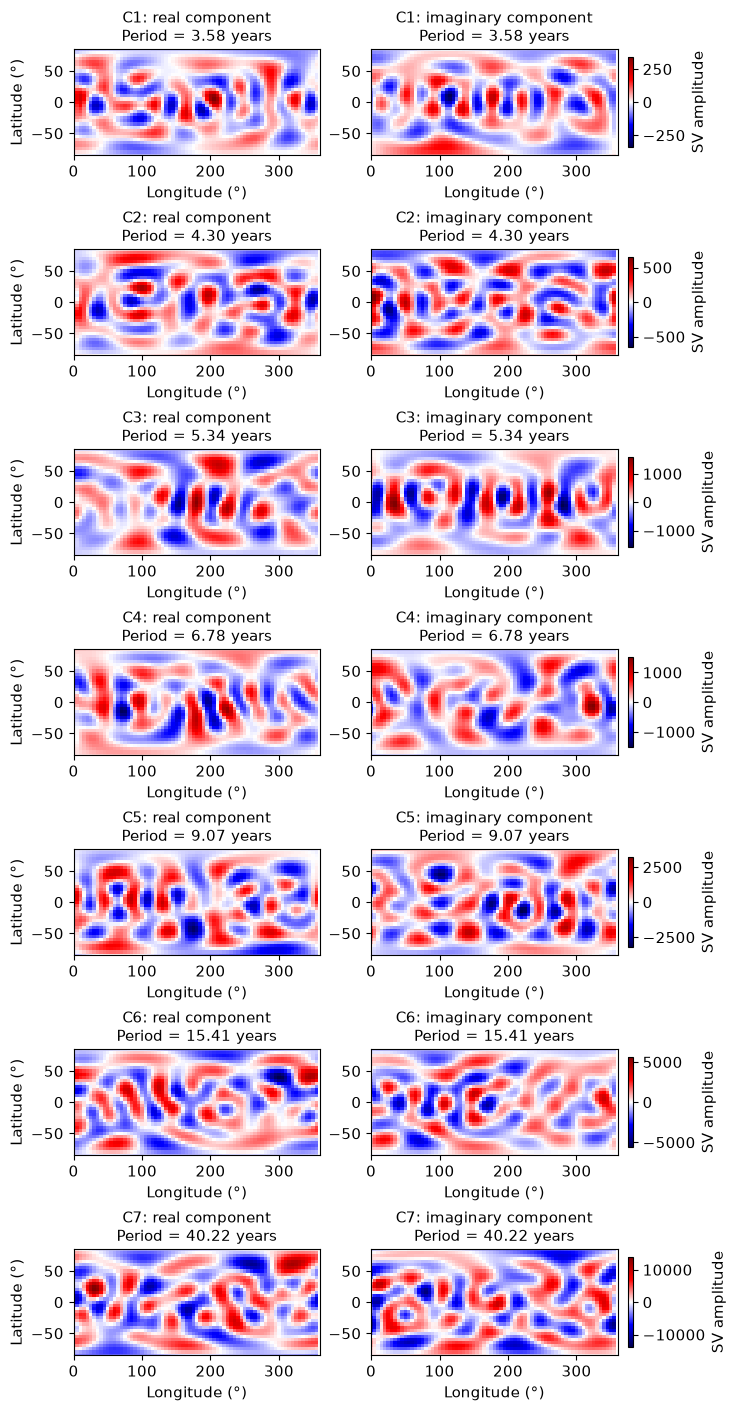

In [ ]:
control_figure, control_axes = Plot_Mode_Phasors(
    control_modes,
    nmax=chosen_nmax,
    figure_width=text_width,
)
plt.show()

In [ ]:
Plot_Mode_Suite_Video_Mollweide(control_modes, times_used_relative, output_path=f"{FIG_DIR}/hidden_waves_set.mp4")

Saved video to: /home/elliott/projects/msc_thesis_project/figures/hidden_waves_set.mp4


PosixPath('/home/elliott/projects/msc_thesis_project/figures/hidden_waves_set.mp4')

In [ ]:
# seeing how these perform under uncertainty:

chosen_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'background',
}
control_results, total_unmatched_periods, recovered_control_modes = (
    Pipeline_Run(
        record_dict_global,
        control_modes,
        chosen_dmd_settings.copy(),
        nmax=chosen_nmax,
        svd_rank=chosen_svd_rank,
        ensemble_settings=chosen_ensemble_settings,
        syn_record=False,
        total_unmatched_period_return=True,
    )
)
control_results = Ensemble_To_Median(control_results, control_modes)
control_similarity_threshold = similarity_thresholds[
    'full_match'
][str(chosen_nmax)]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.5336315113352802e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 828988.7344703646. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition

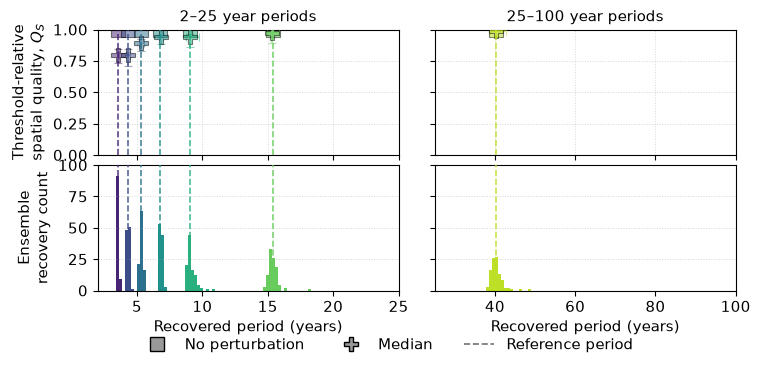

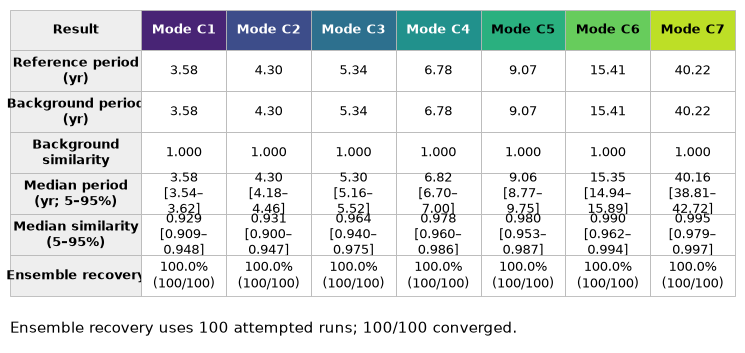

In [ ]:
recovery_figure, recovery_axes = Plot_Single_Run_Ensemble_Results(
    control_results,
    control_modes,
    total_unmatched_periods,
    control_similarity_threshold,
    record_markers,
    record_plotting_params,
    figure_width=text_width,
    non_perturbed_record='background',
)

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    control_results,
    control_modes,
    non_perturbed_record='background',
    ensemble_percentage_basis='attempted',
    figure_width=text_width,
)
plt.show()

In [ ]:
chosen_nmax = 9
chosen_svd_rank = 15
chosen_embedding_d = 6
minimum_period = 3.0
wave_period_boundary = 24.0
slice_latitude = 0.0
slice_longitude = 95.0
font_size = 11

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}

plt.rcParams.update({
    'font.size': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'legend.fontsize': font_size,
})

In [ ]:
gnm_chaos = record_dict_global["background"]
A_chaos_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_chaos = Truncate_Gauss_Coeffs(gnm_chaos, tmax=chosen_nmax)
chaos_sv_grid = A_chaos_r @ gnm_chaos.T

chaos_dmd_modes = Run_DMD(
    chaos_sv_grid,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)

recovered_periods = np.asarray(chaos_dmd_modes['periods'], dtype=float)
recovered_eigenvalues = np.asarray(
    chaos_dmd_modes['continuous_eigenvalues'],
    dtype=complex,
)
recovered_phasors = np.asarray(chaos_dmd_modes['phasors'], dtype=complex)
static_mask = np.isclose(recovered_eigenvalues.imag, 0.0)
selected_mask = static_mask | (
    np.isfinite(recovered_periods)
    & (recovered_periods > minimum_period)
)
selected_indices = np.flatnonzero(selected_mask)

feasible_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] <= wave_period_boundary)
]
feasible_indices = feasible_indices[
    np.argsort(recovered_periods[feasible_indices])[::-1]
]
long_period_indices = selected_indices[
    (~static_mask[selected_indices])
    & (recovered_periods[selected_indices] > wave_period_boundary)
]
long_period_indices = long_period_indices[
    np.argsort(recovered_periods[long_period_indices])[::-1]
]
static_indices = selected_indices[static_mask[selected_indices]]
long_or_static_indices = np.concatenate([
    long_period_indices,
    static_indices,
]).astype(int)

chaos_mode_suite = {}
for mode_number, mode_index in enumerate(feasible_indices, start=1):
    chaos_mode_suite[f'mode_{mode_number}'] = {
        'label': f'Mode {mode_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'feasible',
    }

for long_number, mode_index in enumerate(long_period_indices, start=1):
    chaos_mode_suite[f'long_period_{long_number}'] = {
        'label': f'Long Period Wave {long_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': recovered_periods[mode_index],
        'mode_index': int(mode_index),
        'category': 'long_period',
    }

for static_number, mode_index in enumerate(static_indices, start=1):

    chaos_mode_suite[f'static_{static_number}'] = {
        'label': f'Static Field {static_number}',
        'phasor': recovered_phasors[mode_index],
        'eigenvalue': recovered_eigenvalues[mode_index],
        'period': np.inf,
        'mode_index': int(mode_index),
        'category': 'static',
    }

feasible_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] == 'feasible'
]
long_or_static_mode_keys = [
    key for key, info in chaos_mode_suite.items()
    if info['category'] in {'long_period', 'static'}
]

print(f"Effective DMD rank: {chaos_dmd_modes['effective_rank']}")
print(f'Retained modes with period > {minimum_period:g} years: '
      f'{len(chaos_mode_suite)}')
for mode_info in chaos_mode_suite.values():
    eigenvalue = mode_info['eigenvalue']
    if mode_info['category'] == 'static':
        period_text = 'no imaginary component'
    else:
        period_text = f"{mode_info['period']:.2f} years"
    print(
        f"  {mode_info['label']}: {period_text}; "
        f"lambda = {eigenvalue.real:.4f} "
        f"{eigenvalue.imag:+.4f}i yr^-1"
    )

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 198708.2777802396. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


Effective DMD rank: 15
Retained modes with period > 3 years: 8
  Mode 1: 15.41 years; lambda = -0.0508 +0.4078i yr^-1
  Mode 2: 9.07 years; lambda = -0.0740 +0.6929i yr^-1
  Mode 3: 6.78 years; lambda = -0.0187 +0.9271i yr^-1
  Mode 4: 5.34 years; lambda = -0.0759 +1.1773i yr^-1
  Mode 5: 4.30 years; lambda = -0.0367 +1.4625i yr^-1
  Mode 6: 3.58 years; lambda = 0.0160 +1.7535i yr^-1
  Long Period Wave 1: 40.22 years; lambda = -0.0352 +0.1562i yr^-1
  Static Field 1: no imaginary component; lambda = -0.0640 +0.0000i yr^-1


/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)


In [ ]:
def Evaluate_Recovered_Mode(mode_info, times=times_used_relative):
    phasor = np.asarray(mode_info['phasor'], dtype=complex).ravel()
    eigenvalue = complex(mode_info['eigenvalue'])
    dynamics = np.exp(eigenvalue * np.asarray(times, dtype=float))
    return np.real(dynamics[:, None] * phasor[None, :])


def Format_Eigenvalue(eigenvalue):
    eigenvalue = complex(eigenvalue)
    sign = '+' if eigenvalue.imag >= 0 else '-'
    return (
        rf'$\lambda={eigenvalue.real:.3f}{sign}'
        rf'{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$'
    )


def Period_Text(mode_info):
    if mode_info['category'] == 'static':
        return r'$T = \infty$'
    return f"T = {mode_info['period']:.2f} yr"


longitude_plot = ((np.asarray(longitude) + 180) % 360) - 180
longitude_order = np.argsort(longitude_plot)
longitude_plot = longitude_plot[longitude_order]


def Add_Cyclic_Longitude(field):
    field = np.asarray(field)[..., longitude_order]
    return add_cyclic_point(field, coord=longitude_plot, axis=-1)


def Resolve_Grid_Slices(requested_latitude, requested_longitude):
    requested_latitude = float(requested_latitude)
    requested_longitude = float(requested_longitude)
    longitude_modulo = np.mod(requested_longitude, 360.0)

    latitude_indices = np.flatnonzero(
        np.isclose(latitude, requested_latitude)
    )
    longitude_indices = np.flatnonzero(
        np.isclose(np.mod(longitude, 360.0), longitude_modulo)
    )
    if latitude_indices.size != 1:
        raise ValueError(
            f'Slice latitude {requested_latitude:g}° is not a unique '
            'latitude on the DMD grid.'
        )
    if longitude_indices.size != 1:
        raise ValueError(
            f'Slice longitude {requested_longitude:g}° is not a unique '
            'longitude on the DMD grid.'
        )

    plotted_longitude = ((longitude_modulo + 180.0) % 360.0) - 180.0
    return (
        requested_latitude,
        plotted_longitude,
        int(latitude_indices[0]),
        int(longitude_indices[0]),
    )


def Format_Latitude(latitude_value):
    if np.isclose(latitude_value, 0.0):
        return '0° latitude'
    hemisphere = 'N' if latitude_value > 0 else 'S'
    return f'{abs(latitude_value):g}°{hemisphere}'


def Format_Longitude(longitude_value):
    if np.isclose(longitude_value, 0.0):
        return '0° longitude'
    if np.isclose(abs(longitude_value), 180.0):
        return '180° longitude'
    hemisphere = 'E' if longitude_value > 0 else 'W'
    return f'{abs(longitude_value):g}°{hemisphere}'


def Format_Compact_Colourbar_Value(value):
    value = float(value)
    if np.isclose(value, 0.0):
        return '0'
    exponent = int(np.floor(np.log10(abs(value))))
    if abs(exponent) >= 3:
        mantissa = value / (10.0 ** exponent)
        return rf'${mantissa:.2g}\times10^{{{exponent}}}$'
    return f'{value:.3g}'


def Add_Compact_Horizontal_Colourbar(
    fig,
    grid_cell,
    mappable,
    minimum,
    maximum,
    label,
    font_size,
):
    host_axis = fig.add_subplot(grid_cell)
    host_axis.axis('off')
    colourbar_axis = host_axis.inset_axes([0.22, 0.48, 0.56, 0.20])
    colourbar = fig.colorbar(
        mappable,
        cax=colourbar_axis,
        orientation='horizontal',
    )
    colourbar.set_ticks([])
    colourbar_axis.set_xlabel(
        label,
        fontsize=font_size,
        labelpad=3,
    )
    host_axis.text(
        0.19,
        0.58,
        Format_Compact_Colourbar_Value(minimum),
        transform=host_axis.transAxes,
        ha='right',
        va='center',
        fontsize=font_size - 1,
    )
    host_axis.text(
        0.81,
        0.58,
        Format_Compact_Colourbar_Value(maximum),
        transform=host_axis.transAxes,
        ha='left',
        va='center',
        fontsize=font_size - 1,
    )
    return colourbar


def Style_Geographic_Axis(
    axis,
    coastline_colour='0.15',
    coastline_linewidth=0.45,
    gridline_colour='0.15',
    draw_gridline_labels=False,
    slice_latitude=None,
    slice_longitude=None,
    slice_colour='white',
):
    axis.set_global()
    axis.coastlines(
        resolution='110m',
        color=coastline_colour,
        linewidth=coastline_linewidth,
    )
    gridliner = axis.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=draw_gridline_labels,
        xlocs=np.arange(-180, 181, 60),
        ylocs=np.arange(-60, 61, 30),
        color=gridline_colour,
        linewidth=0.45,
        alpha=0.35,
        linestyle=':',
        x_inline=False,
        y_inline=False,
    )
    gridliner.top_labels = False
    gridliner.right_labels = False

    if slice_latitude is not None:
        axis.plot(
            np.linspace(-180, 180, 361),
            np.full(361, slice_latitude),
            transform=ccrs.PlateCarree(),
            color=slice_colour,
            linewidth=1.15,
            linestyle='--',
            zorder=5,
        )
    if slice_longitude is not None:
        axis.plot(
            np.full(181, slice_longitude),
            np.linspace(-90, 90, 181),
            transform=ccrs.PlateCarree(),
            color=slice_colour,
            linewidth=1.15,
            linestyle=(0, (5, 2, 1, 2)),
            zorder=5,
        )

    return gridliner


def Plot_CHAOS_Phasors(
    mode_suite,
    mode_keys,
    figure_width=text_width,
    row_height=1.12,
    font_size=11,
    slice_latitude=None,
    slice_longitude=None,
    show_gridline_labels=False,
):
    if not mode_keys:
        raise ValueError('At least one mode is required for a phasor plot.')
    if (slice_latitude is None) != (slice_longitude is None):
        raise ValueError(
            'slice_latitude and slice_longitude must be supplied together.'
        )
    if slice_latitude is not None:
        (
            slice_latitude,
            slice_longitude,
            _,
            _,
        ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)

    n_modes = len(mode_keys)
    figure_height = row_height * n_modes + 0.90
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        n_modes + 2,
        3,
        width_ratios=(1.15, 2.35, 2.35),
        height_ratios=[0.12] + ([1.0] * n_modes) + [0.10],
    )
    axes = np.empty((n_modes, 2), dtype=object)
    for column, column_label in enumerate(
        ('Real', 'Imaginary'),
        start=1,
    ):
        heading_axis = fig.add_subplot(grid[0, column])
        heading_axis.axis('off')
        heading_axis.text(
            0.5,
            0.0,
            column_label,
            transform=heading_axis.transAxes,
            ha='center',
            va='bottom',
            fontsize=font_size,
        )

    phasor_grids = {}
    colour_values = []
    for mode_key in mode_keys:
        phasor_grid = np.asarray(
            mode_suite[mode_key]['phasor'],
            dtype=complex,
        ).reshape(state_shape)
        real_grid, cyclic_longitude = Add_Cyclic_Longitude(
            phasor_grid.real
        )
        imaginary_grid, _ = Add_Cyclic_Longitude(phasor_grid.imag)
        phasor_grids[mode_key] = (
            real_grid,
            imaginary_grid,
            cyclic_longitude,
        )
        colour_values.extend([real_grid.ravel(), imaginary_grid.ravel()])

    colour_limit = np.nanmax(np.abs(np.concatenate(colour_values)))
    if not np.isfinite(colour_limit) or colour_limit == 0:
        colour_limit = 1.0

    for row, mode_key in enumerate(mode_keys):
        mode_info = mode_suite[mode_key]
        real_grid, imaginary_grid, cyclic_longitude = phasor_grids[mode_key]
        eigenvalue = complex(mode_info['eigenvalue'])
        sign = '+' if eigenvalue.imag >= 0 else '-'

        information_axis = fig.add_subplot(grid[row + 1, 0])
        information_axis.axis('off')
        information_axis.text(
            0.98,
            0.5,
            (
                f"{mode_info['label']}\n"
                rf"$\lambda={eigenvalue.real:.3f}$" '\n'
                rf"${sign}{abs(eigenvalue.imag):.3f}i$ yr$^{{-1}}$" '\n'
                f"{Period_Text(mode_info)}"
            ),
            transform=information_axis.transAxes,
            ha='right',
            va='center',
            fontsize=font_size,
            linespacing=1.15,
        )

        axes[row, 0] = fig.add_subplot(
            grid[row + 1, 1],
            projection=ccrs.Robinson(central_longitude=0),
        )
        axes[row, 1] = fig.add_subplot(
            grid[row + 1, 2],
            projection=ccrs.Robinson(central_longitude=0),
        )
        real_mesh = axes[row, 0].pcolormesh(
            cyclic_longitude,
            latitude,
            real_grid,
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='PuOr',
            vmin=-colour_limit,
            vmax=colour_limit,
            rasterized=True,
        )

        if mode_info['category'] == 'static':
            axes[row, 1].text(
                0.5,
                0.5,
                'No imaginary\ncomponent',
                transform=axes[row, 1].transAxes,
                ha='center',
                va='center',
                fontsize=font_size,
            )
        else:
            axes[row, 1].pcolormesh(
                cyclic_longitude,
                latitude,
                imaginary_grid,
                transform=ccrs.PlateCarree(),
                shading='auto',
                cmap='PuOr',
                vmin=-colour_limit,
                vmax=colour_limit,
                rasterized=True,
            )

        for column, axis in enumerate(axes[row]):
            gridliner = Style_Geographic_Axis(
                axis,
                draw_gridline_labels=show_gridline_labels,
                slice_latitude=slice_latitude,
                slice_longitude=slice_longitude,
                slice_colour='0.15',
            )
            if show_gridline_labels:
                gridliner.bottom_labels = False
                gridliner.left_labels = (column == 0)
    colourbar_axis = fig.add_subplot(grid[-1, 1:])
    colourbar = fig.colorbar(
        real_mesh,
        cax=colourbar_axis,
        orientation='horizontal',
    )
    colourbar.set_label(r'Radial SV (nT yr$^{-1}$)')
    colourbar.ax.tick_params(labelsize=font_size)

    return fig, axes


def Plot_Equatorial_And_Power(
    record_suite,
    slice_latitude,
    slice_longitude,
    figure_width=text_width,
    font_size=11,
):
    if not record_suite:
        raise ValueError('At least one reconstructed record is required.')

    (
        slice_latitude,
        slice_longitude,
        slice_latitude_index,
        slice_longitude_index,
    ) = Resolve_Grid_Slices(slice_latitude, slice_longitude)
    latitude_order = np.argsort(latitude)
    latitude_plot = np.asarray(latitude)[latitude_order]
    latitude_spacing = np.median(np.diff(latitude_plot))

    n_rows = len(record_suite)
    figure_height = max(2.90 * n_rows + 0.25, 3.85)
    fig = plt.figure(
        figsize=(figure_width, figure_height),
        constrained_layout=True,
    )
    grid = fig.add_gridspec(
        2 * n_rows,
        3,
        height_ratios=[1.0, 0.17] * n_rows,
        width_ratios=(2.45, 1.05, 1.05),
    )
    axes = []
    expected_shape = (len(times_used), np.prod(state_shape))
    prepared_records = {}

    for label, record in record_suite.items():
        record = np.asarray(record, dtype=float)
        if record.shape != expected_shape:
            raise ValueError(
                f"Record '{label}' has shape {record.shape}; "
                f"expected {expected_shape}."
            )
        record_grid = record.reshape(len(times_used), *state_shape)
        latitude_slice_sv = record_grid[
            :, slice_latitude_index, :
        ][:, longitude_order]
        longitude_slice_sv = record_grid[
            :, latitude_order, slice_longitude_index
        ]
        mean_power = np.mean(record_grid ** 2, axis=0)
        power_grid, cyclic_longitude = Add_Cyclic_Longitude(mean_power)

        sv_limit = np.nanmax(np.abs(np.concatenate([
            latitude_slice_sv.ravel(),
            longitude_slice_sv.ravel(),
        ])))
        if not np.isfinite(sv_limit) or sv_limit == 0:
            sv_limit = 1.0

        finite_power_values = power_grid[np.isfinite(power_grid)]
        if finite_power_values.size == 0:
            raise ValueError(
                f"Power field for '{label}' contains no finite values."
            )
        power_limit = np.max(finite_power_values)
        if power_limit <= 0:
            power_limit = 1.0

        prepared_records[label] = (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
            sv_limit,
        )

    latitude_slice_extent = (
        -180,
        180,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )
    longitude_slice_extent = (
        latitude_plot[0] - latitude_spacing / 2,
        latitude_plot[-1] + latitude_spacing / 2,
        times_used[0] - dt_sample / 2,
        times_used[-1] + dt_sample / 2,
    )
    for row, label in enumerate(record_suite):
        (
            power_grid,
            cyclic_longitude,
            latitude_slice_sv,
            longitude_slice_sv,
            power_limit,
            sv_limit,
        ) = prepared_records[label]
        data_row = 2 * row
        colourbar_row = data_row + 1

        power_axis = fig.add_subplot(
            grid[data_row, 0],
            projection=ccrs.Robinson(central_longitude=0),
        )
        power_mesh = power_axis.pcolormesh(
            cyclic_longitude,
            latitude,
            np.ma.masked_less_equal(power_grid, 0.0),
            transform=ccrs.PlateCarree(),
            shading='auto',
            cmap='magma',
            vmin=0.0,
            vmax=power_limit,
            rasterized=True,
        )
        Style_Geographic_Axis(
            power_axis,
            coastline_colour='white',
            coastline_linewidth=0.70,
            gridline_colour='white',
            slice_latitude=slice_latitude,
            slice_longitude=slice_longitude,
            slice_colour='white',
        )
        power_axis.set_title(
            label.replace('\n', '  |  '),
            pad=3,
            fontweight='semibold',
        )

        latitude_slice_axis = fig.add_subplot(grid[data_row, 1])
        latitude_slice_image = latitude_slice_axis.imshow(
            latitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=latitude_slice_extent,
            cmap='seismic',
            vmin=-sv_limit,
            vmax=sv_limit,
            interpolation='nearest',
            rasterized=True,
        )
        latitude_slice_axis.set_ylabel('Year')
        latitude_slice_axis.set_yticks([2000, 2008, 2016, 2024])
        latitude_slice_axis.set_xlim(-180, 180)
        latitude_slice_axis.set_xticks([-180, -90, 0, 90, 180])
        if row == 0:
            latitude_slice_axis.set_title(
                f'Radial SV at {Format_Latitude(slice_latitude)}',
                pad=2,
            )
        latitude_slice_axis.set_xlabel('Longitude (°)')

        longitude_slice_axis = fig.add_subplot(grid[data_row, 2])
        longitude_slice_image = longitude_slice_axis.imshow(
            longitude_slice_sv,
            origin='lower',
            aspect='auto',
            extent=longitude_slice_extent,
            cmap='seismic',
            vmin=-sv_limit,
            vmax=sv_limit,
            interpolation='nearest',
            rasterized=True,
        )
        longitude_slice_axis.set_ylabel('Year')
        longitude_slice_axis.set_yticks([2000, 2008, 2016, 2024])
        longitude_slice_axis.set_xlim(
            latitude_plot[0],
            latitude_plot[-1],
        )
        longitude_slice_axis.set_xticks([-80, -40, 0, 40, 80])
        if row == 0:
            longitude_slice_axis.set_title(
                f'Radial SV at {Format_Longitude(slice_longitude)}',
                pad=2,
            )
        longitude_slice_axis.set_xlabel('Latitude (°)')

        Add_Compact_Horizontal_Colourbar(
            fig,
            grid[colourbar_row, 0],
            power_mesh,
            minimum=0.0,
            maximum=power_limit,
            label=r'Mean power ((nT yr$^{-1}$)$^2$)',
            font_size=font_size,
        )
        Add_Compact_Horizontal_Colourbar(
            fig,
            grid[colourbar_row, 1:],
            latitude_slice_image,
            minimum=-sv_limit,
            maximum=sv_limit,
            label=r'Radial SV (nT yr$^{-1}$)',
            font_size=font_size,
        )

        axes.append((
            power_axis,
            latitude_slice_axis,
            longitude_slice_axis,
        ))

    return fig, np.asarray(axes, dtype=object)

In [ ]:
mode_records = {
    mode_key: Evaluate_Recovered_Mode(mode_info)
    for mode_key, mode_info in chaos_mode_suite.items()
}
chaos_record = chaos_sv_grid.T
expected_record_shape = (len(times_used), np.prod(state_shape))
if chaos_record.shape != expected_record_shape:
    raise ValueError(
        f'CHAOS record has shape {chaos_record.shape}; '
        f'expected {expected_record_shape}.'
    )

long_period_sum = np.zeros_like(chaos_record, dtype=float)
for mode_key in long_or_static_mode_keys:
    long_period_sum += mode_records[mode_key]

cumulative_records = {'LP': long_period_sum.copy()}
running_sum = long_period_sum.copy()
included_mode_numbers = []
for mode_number, mode_key in enumerate(feasible_mode_keys, start=1):
    if mode_number not in [4, 5]:
        running_sum = running_sum + mode_records[mode_key]
        included_mode_numbers.append(str(mode_number))
        cumulative_label = 'LP+' + '+'.join(included_mode_numbers)
        cumulative_records[cumulative_label] = running_sum.copy()

area_weights = np.asarray(W2D_norm, dtype=float).ravel()
if area_weights.size != chaos_record.shape[1]:
    raise ValueError('Area weights do not match the DMD spatial grid.')
if not np.isclose(np.sum(area_weights), 1.0):
    raise ValueError('Expected normalized area weights to sum to one.')

cumulative_rms_misfit = {}
for label, reconstruction in cumulative_records.items():
    residual = chaos_record - reconstruction
    cumulative_rms_misfit[label] = np.sqrt(
        np.sum(area_weights[None, :] * residual ** 2, axis=1)
    )

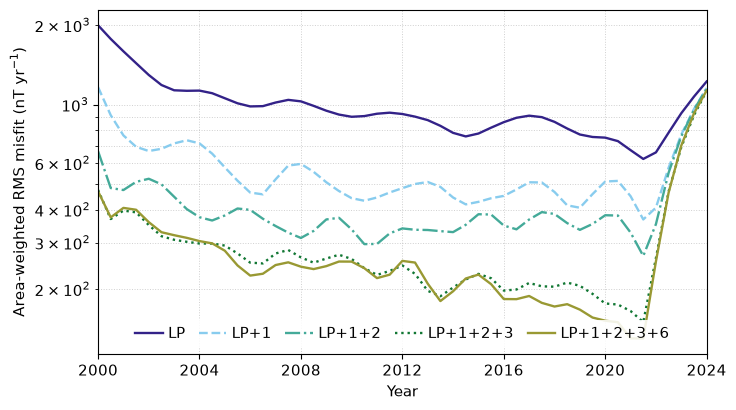

In [ ]:
misfit_figure, misfit_axis = plt.subplots(
    figsize=(text_width, 0.55 * text_width),
    constrained_layout=True,
)
line_styles = ['-', '--', '-.', ':']
for line_index, (label, rms_misfit) in enumerate(
    cumulative_rms_misfit.items()
):
    misfit_axis.semilogy(
        times_used,
        rms_misfit,
        color=tol_muted[line_index % len(tol_muted)],
        linestyle=line_styles[line_index % len(line_styles)],
        linewidth=1.7,
        label=label,
    )
misfit_axis.set(
    xlim=(times_used[0], times_used[-1]),
    xlabel='Year',
    ylabel=r'Area-weighted RMS misfit (nT yr$^{-1}$)',
)
misfit_axis.set_xticks(np.arange(2000, 2025, 4))
misfit_axis.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.6)
misfit_axis.legend(
    frameon=True,
    framealpha=0.88,
    edgecolor='none',
    ncol=len(cumulative_rms_misfit),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    borderaxespad=0.2,
    columnspacing=0.9,
    handlelength=1.8,
    handletextpad=0.35,
)
plt.show()

In [ ]:
mode_records = {
    mode_key: Evaluate_Recovered_Mode(mode_info)
    for mode_key, mode_info in chaos_mode_suite.items()
}
chaos_record = chaos_sv_grid.T
expected_record_shape = (len(times_used), np.prod(state_shape))
if chaos_record.shape != expected_record_shape:
    raise ValueError(
        f'CHAOS record has shape {chaos_record.shape}; '
        f'expected {expected_record_shape}.'
    )

long_period_sum = np.zeros_like(chaos_record, dtype=float)
for mode_key in long_or_static_mode_keys:
    long_period_sum += mode_records[mode_key]

cumulative_records = {'LP': long_period_sum.copy()}
running_sum = long_period_sum.copy()
included_mode_numbers = []
for mode_number, mode_key in enumerate(feasible_mode_keys, start=1):

    running_sum = running_sum + mode_records[mode_key]
    included_mode_numbers.append(str(mode_number))
    cumulative_label = 'LP+' + '+'.join(included_mode_numbers)
    cumulative_records[cumulative_label] = running_sum.copy()

area_weights = np.asarray(W2D_norm, dtype=float).ravel()
if area_weights.size != chaos_record.shape[1]:
    raise ValueError('Area weights do not match the DMD spatial grid.')
if not np.isclose(np.sum(area_weights), 1.0):
    raise ValueError('Expected normalized area weights to sum to one.')

cumulative_rms_misfit = {}
for label, reconstruction in cumulative_records.items():
    residual = chaos_record - reconstruction
    cumulative_rms_misfit[label] = np.sqrt(
        np.sum(area_weights[None, :] * residual ** 2, axis=1)
    )

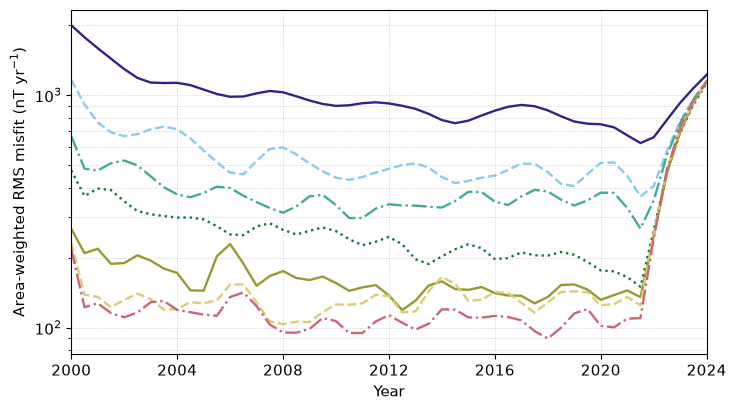

In [ ]:
misfit_figure, misfit_axis = plt.subplots(
    figsize=(text_width, 0.55 * text_width),
    constrained_layout=True,
)
line_styles = ['-', '--', '-.', ':']
for line_index, (label, rms_misfit) in enumerate(
    cumulative_rms_misfit.items()
):
    misfit_axis.semilogy(
        times_used,
        rms_misfit,
        color=tol_muted[line_index % len(tol_muted)],
        linestyle=line_styles[line_index % len(line_styles)],
        linewidth=1.7,
        label=label,
    )
misfit_axis.set(
    xlim=(times_used[0], times_used[-1]),
    xlabel='Year',
    ylabel=r'Area-weighted RMS misfit (nT yr$^{-1}$)',
)
misfit_axis.set_xticks(np.arange(2000, 2025, 4))
misfit_axis.grid(True, which='both', linestyle=':', linewidth=0.7, alpha=0.6)
'''misfit_axis.legend(
    frameon=True,
    framealpha=0.88,
    edgecolor='none',
    ncol=len(cumulative_rms_misfit),
    loc='lower center',
    bbox_to_anchor=(0.5, 0.01),
    borderaxespad=0.2,
    columnspacing=0.9,
    handlelength=1.8,
    handletextpad=0.35,
)'''
plt.show()